# <b>Loan Default Risk Prediction</b>

## <b>Exploratory Data Analysis (EDA)</b>

### <b>Session 1: Dataset Overview</b>

**Objective:**

The objective of this session is to understand the overall structure of the dataset before performing any preprocessing or feature engineering.

In this session, we will:

- Load the dataset using the Data Ingestion Pipeline
- Inspect the dataset structure
- Understand the dimensions of the dataset
- Identify numerical and categorical features
- Check missing values and duplicate records

#### <b>Step 1: Import Required Libraries</b>

We begin by importing the required libraries for data manipulation and loading the dataset.

Notice that we are **not using `pd.read_csv()` directly**. Instead, we load the data through our production Data Ingestion component.

In [1]:
import pandas as pd
import numpy as np

from src.components.data_ingestion import DataIngestion

#### <b>Step 2: Load Dataset</b>

The dataset is loaded using the Data Ingestion pipeline.

Using a centralized ingestion component improves maintainability because any future change in the data source only needs to be updated in one place.

In [2]:
ingestion  = DataIngestion()
df = ingestion.load_data()

[2026-07-22 16:15:35,110] INFO - loan_default_project - Loading dataset from: D:\MachineLearningProjects\Loan_Default_Risk_Prediction\data\raw\application_train.csv
[2026-07-22 16:15:42,090] INFO - loan_default_project - Dataset loaded successfully with shape: (307511, 122)


#### <b>Step 3: Display First Five Records</b>

The `head()` function displays the first five rows of the dataset.

This helps us verify:

- Column names
- Data types
- Sample values
- Overall dataset structure

Instead of printing the complete dataset, which contains more than 300,000 records, we inspect only a small sample.

In [3]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


##### <b>Observation</b>

- The dataset contains customer demographic and financial information.
- Each row represents one loan application.
- The target variable is **TARGET**.
- The dataset contains both numerical and categorical variables.

#### <b>Step 4: Check Dataset Shape</b>

The shape of the dataset tells us the number of rows and columns available for analysis.

In [4]:
df.shape

(307511, 122)

##### <b>Observation</b>

The dataset contains:

- **307,511 rows**
- **122 columns**

This indicates a relatively large dataset with many features that will require preprocessing before model training.

#### <b>Step 5: Dataset Information</b>

The `info()` function provides:

- Number of rows
- Number of columns
- Non-null values
- Data types
- Memory usage

This is one of the first commands every Data Scientist runs before starting EDA.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


##### <b>Observation</b>

From the dataset information we observe:

- Multiple columns contain missing values.
- Both numerical and categorical features are present.
- Most numerical columns are stored as `float64` or `int64`.
- Several categorical columns are stored as `object`.

#### <b>Step 6: Statistical Summary</b>

The `describe()` function summarizes the numerical features.

It provides:

- Count
- Mean
- Standard Deviation
- Minimum
- Quartiles
- Maximum

In [6]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


##### <b>Observation</b>

The statistical summary helps us identify:

- Features with large ranges
- Possible outliers
- Skewed distributions
- Missing values (through reduced count)

#### <b>Step 7: Missing Value Analysis</b>

Before cleaning the data, we identify which columns contain missing values.

This helps us decide the appropriate imputation strategy during preprocessing.

In [7]:
df.isnull().sum().sort_values(ascending=False).head(10)

COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_MODE       210199
dtype: int64

##### <b>Observation</b>

Several columns contain a high percentage of missing values.

These columns will require careful handling during the feature engineering stage.

At this point, we only identify missing values—we do not remove or impute them.

#### <b>Session 1 Summary</b>

In this session we:

- Successfully loaded the dataset
- Understood the dataset dimensions
- Explored the dataset structure
- Identified numerical and categorical features
- Checked duplicate records
- Identified missing values
- Generated initial business observations

The dataset is now ready for deeper exploratory analysis in the next session.

### <b>Session 2: Target Variable Analysis</b>

**Objective**

The objective of this session is to understand the distribution of the target variable and determine whether the dataset is balanced or imbalanced.

The target variable is `TARGET`, where:

- `0` represents a customer who repaid the loan or did not experience payment difficulty.
- `1` represents a customer who defaulted or experienced payment difficulty.

Target analysis is important because class distribution directly affects model training, evaluation metrics, and sampling strategies.

#### <b>Business Context</b>

The organization wants to identify customers who are likely to default before approving a loan.

In this business problem:

- Correctly identifying a defaulter helps reduce financial loss.
- Missing an actual defaulter can be costly.
- Incorrectly classifying a reliable customer as risky may result in additional verification or rejection of a potentially profitable customer.

Therefore, understanding the number of defaulters and non-defaulters is essential before building the classification model.

#### <b>Step 1: Verify the Target Column</b>

Before analyzing the target variable, we first confirm that the `TARGET` column is present in the dataset.

This prevents the analysis from continuing with an incomplete or incorrect dataset.

In [8]:
target_column = "TARGET"
if target_column not in df.columns:
    raise ValueError(f"Target Column `{target_column}` is missing from the dataset.")
print(f"Target Column '{target_column}' is present.")

Target Column 'TARGET' is present.


#### <b>Step 2: Check Unique Values in the Target Column</b>

A binary classification target should contain two valid classes.

For this project, the expected values are:

- `0`: No default
- `1`: Default

Checking unique values also helps identify unexpected labels or data-quality problems.

In [9]:
target_values = sorted(df[target_column].dropna().unique().tolist())
print(f"Unique target values: {target_values}")

Unique target values: [0, 1]


##### <b>Observation</b>

The `TARGET` column contains two unique values: `0` and `1`.

Therefore, this is a binary classification problem.

No unexpected target labels were identified.

#### <b>Step 3: Check Missing Values in the Target Column</b>

The target column must contain valid labels for model training.

Rows with a missing target cannot be directly used in supervised learning because the expected outcome is unknown.

In [10]:
target_missing_count = df[target_column].isnull().sum()
target_missing_percentage = (
    target_missing_count / len(df)
) * 100

print("Missing target values:", target_missing_count)
print(f"Missing target percentage: {target_missing_percentage:.2f}%")

Missing target values: 0
Missing target percentage: 0.00%


##### <b>Observation</b>

The `TARGET` column does not contain any missing values.

This means every record has a known loan repayment outcome and can potentially be used for supervised model training.

#### <b>Step 4: Calculate the Number of Records in Each Target Class</b>

The `value_counts()` function calculates how many customers belong to each target category.

This helps us compare the number of non-default and default cases.

In [11]:
target_counts = df[target_column].value_counts().sort_index()
print(target_counts)

TARGET
0    282686
1     24825
Name: count, dtype: int64


##### <b>Observation</b>

The dataset contains approximately:

- **282,686 non-default customers**
- **24,825 default customers**

The number of customers who did not default is substantially higher than the number of customers who defaulted.

#### <b>Step 5: Calculate the Percentage Distribution of the Target</b>

Counts show the absolute number of records, while percentages make it easier to understand the relative distribution of each class.

In [12]:
target_percentage = df[target_column].value_counts(normalize=True).sort_index().mul(100).round(2)

print(target_percentage)

TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


##### <b>Observation</b>

Approximately:

- **91.93%** of customers belong to the non-default class.
- **8.07%** of customers belong to the default class.

The target classes are not equally distributed. The default class is significantly smaller than the non-default class.

#### <b>Step 6: Create a Target Distribution Summary</b>

A summary table combines target labels, customer counts, and class percentages in a clear and readable format.

In [13]:
target_summary = pd.DataFrame({
    "Target": target_counts.index,
    "Customer_Count": target_counts.values,
    "Percentage": target_percentage.values
})

target_summary['Class_Label'] = target_summary['Target'].map(
    {
        0: "No Default",
        1: "Default"
    }
)

target_summary = target_summary[
    [
        "Target",
        "Class_Label",
        "Customer_Count",
        "Percentage"
    ]
]

print(target_summary)

   Target Class_Label  Customer_Count  Percentage
0       0  No Default          282686       91.93
1       1     Default           24825        8.07


#### <b>Step 7: Visualize the Target Distribution</b>

A bar chart allows us to visually compare the size of the two target classes.

A large difference between the bars indicates class imbalance.

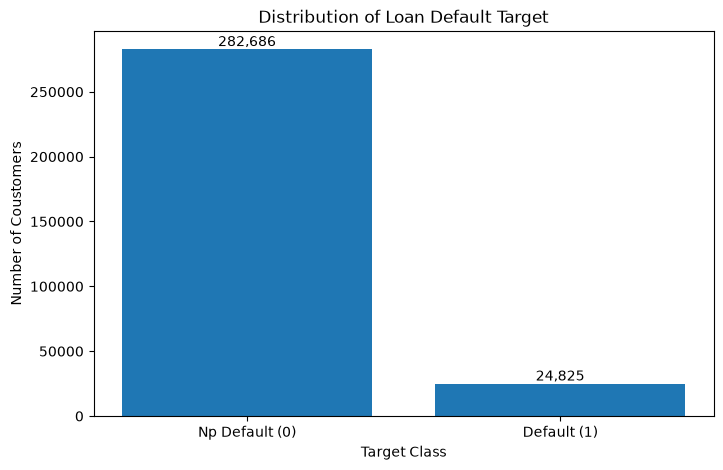

In [14]:
import matplotlib.pyplot as plt

class_labels = ["Np Default (0)", "Default (1)"]
fig,ax = plt.subplots(figsize=(8,5))
bars = ax.bar(class_labels, target_counts.values)
ax.set_title("Distribution of Loan Default Target")
ax.set_xlabel("Target Class")
ax.set_ylabel("Number of Coustomers")

for bar, count in zip(bars, target_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.show()

##### <b>Observation</b>

The non-default class is much larger than the default class.

This confirms that the dataset is imbalanced.

A model trained without considering this imbalance may become biased toward predicting the majority class.

#### <b>Step 8: Visualize the Percentage of Each Target Class</b>

The following chart shows the percentage contribution of each class.

This representation makes the degree of class imbalance easier to interpret.

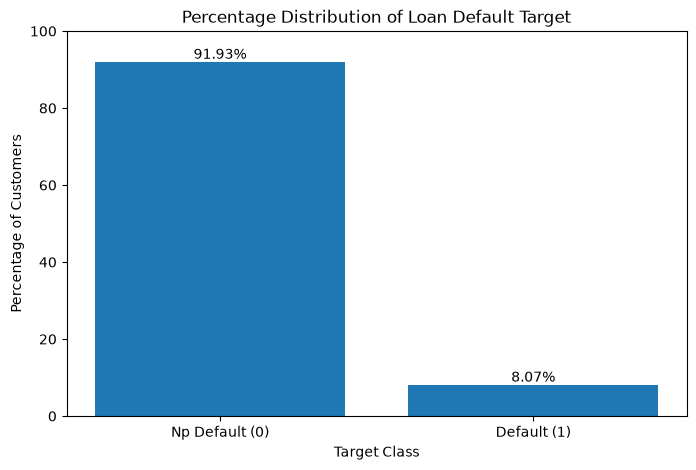

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    class_labels,
    target_percentage.values,
)

ax.set_title("Percentage Distribution of Loan Default Target")
ax.set_xlabel("Target Class")
ax.set_ylabel("Percentage of Customers")
ax.set_ylim(0, 100)

for bar, percentage in zip(bars, target_percentage.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.2f}%",
        ha="center",
        va="bottom",
    )

plt.show()

#### <b>Step 9: Calculate the Class-Imbalance Ratio</b>

The imbalance ratio compares the number of majority-class records with the number of minority-class records.

It helps quantify how much larger the non-default class is than the default class.

In [16]:
non_default_count = target_counts.get(0,0)
default_count = target_counts.get(1,0)

if default_count==0:
    raise ValueError(
        "The default class contains no records. "
        "The imbalance ratio can't be calculated."
    )
imbalance_ratio = non_default_count/default_count
print("Class imbalance ratio: ", f"{imbalance_ratio:.2f}:1")

Class imbalance ratio:  11.39:1


##### <b>Observation</b>

For approximately every one customer who defaults, there are more than eleven customers who do not default.

This is a significant class imbalance and must be considered during:

- Train-test splitting
- Model training
- Model evaluation
- Threshold selection
- Sampling or class-weight decisions

#### <b>Step 10: Why Accuracy Can Be Misleading</b>

Suppose a model predicts every customer as `0`, meaning no customer will default.

Because approximately 91.93% of the records belong to class `0`, this model would achieve approximately 91.93% accuracy.

However, it would fail to identify every actual defaulter.

Therefore, high accuracy does not necessarily mean that the model is useful for the business.

In [17]:
majority_class_accuracy = (
    non_default_count / len(df)
) * 100

print(
    "Accuracy obtained by predicting every customer as non-default:",
    f"{majority_class_accuracy:.2f}%",
)

Accuracy obtained by predicting every customer as non-default: 91.93%


##### <b>Business Interpretation</b>

A model that always predicts `No Default` would achieve high accuracy but would detect none of the actual defaulters.

Such a model would expose the company to financial losses because risky customers could still receive loans.

Therefore, accuracy alone should not be used as the primary model evaluation metric for this project.

#### <b>Step 11: Select Appropriate Evaluation Metrics</b>

Because the dataset is imbalanced, the model should be evaluated using metrics that measure performance on the minority class.

The following metrics will be important:

##### <b>Recall</b>

Recall measures how many actual defaulters are correctly detected.

A high recall means the model misses fewer risky customers.

##### <b>Precision</b>

Precision measures how many customers predicted as defaulters actually defaulted.

A high precision reduces unnecessary rejection or investigation of reliable customers.

##### <b>F1-Score</b>

F1-score balances precision and recall.

It is useful when both false positives and false negatives are important.

##### <b>ROC-AUC</b>

ROC-AUC measures the model's ability to rank default customers above non-default customers across different classification thresholds.

##### <b>PR-AUC</b>

Precision-Recall AUC is especially useful for imbalanced datasets because it focuses more directly on performance for the positive minority class.

##### <b>Metric Priority for This Project</b>

Recall will be an important metric because failing to detect an actual defaulter can cause financial loss.

However, maximizing recall without considering precision may result in too many reliable customers being classified as risky.

Therefore, the final model should balance:

- Recall
- Precision
- F1-score
- ROC-AUC
- Precision-Recall AUC

The final decision threshold should also be selected according to the business cost of false positives and false negatives.

#### <b>Step 12: Business Meaning of Classification Errors</b>

##### <b>False Positive</b>

The model predicts that a customer will default, but the customer would actually repay the loan.

Possible business consequence:

- A reliable customer may face additional verification.
- The loan may be rejected.
- The company may lose a profitable customer.

##### <b>False Negative</b>

The model predicts that a customer will repay the loan, but the customer actually defaults.

Possible business consequence:

- The company may approve a high-risk loan.
- The lender may experience financial loss.
- Recovery and collection costs may increase.

In loan default prediction, false negatives are generally considered especially costly because actual defaulters are missed.

#### <b>Step 13: Modeling Decisions Based on Target Distribution</b>

The target analysis suggests the following modeling decisions:

1. Use a stratified train-test split to preserve the target distribution.
2. Avoid evaluating the model using accuracy alone.
3. Compare recall, precision, F1-score, ROC-AUC, and PR-AUC.
4. Consider class-weighted algorithms.
5. Experiment with sampling techniques only on the training data.
6. Evaluate probability thresholds according to business cost.
7. Compare the model against a majority-class baseline.

##### <b>Important Note About Resampling</b>

Techniques such as SMOTE may be tested later, but they must only be applied to the training dataset.

Applying SMOTE before train-test splitting would create data leakage because synthetic information derived from the complete dataset could influence the test set.

We will compare multiple strategies instead of assuming that SMOTE is automatically the best solution:

- No resampling
- Class weights
- Random undersampling
- Random oversampling
- SMOTE
- Threshold tuning

#### <b>Business Insights</b>

1. Loan defaults represent only a small portion of all applications.
2. Most customers repay their loans, while approximately 8% experience payment difficulty.
3. A model that predicts every customer as non-default can still achieve more than 91% accuracy.
4. Accuracy alone would therefore provide a misleading view of model performance.
5. Missing an actual defaulter may cause direct financial loss.
6. Incorrectly identifying a reliable customer as risky may reduce business opportunities.
7. The final modeling strategy must balance risk reduction with customer approval opportunities.

#### <b>Session 2 Summary</b>

In this session, we:

- Verified the target column
- Confirmed that the problem is binary classification
- Checked missing values in the target
- Calculated target counts and percentages
- Visualized the target distribution
- Measured the class-imbalance ratio
- Demonstrated why accuracy can be misleading
- Identified suitable evaluation metrics
- Interpreted false positives and false negatives
- Defined initial modeling decisions

The dataset is imbalanced, with the default class representing approximately 8% of the observations.

The next session will focus on missing-value analysis across all input features.